In [1]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
#Example 1

data, true_labes = make_blobs(n_samples=300, centers=3, cluster_std=2.0, random_state=42)

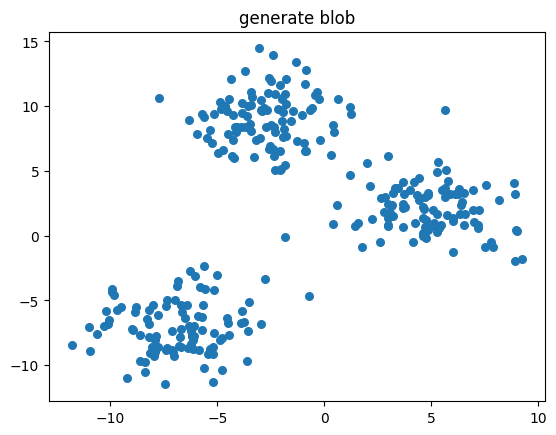

In [3]:
plt.scatter(data[:,0], data[:,1], s=30)
plt.title("generate blob")
plt.show()

In [4]:
gmm = GaussianMixture(n_components=3,random_state=42)

In [5]:
gmm.fit(data)

GaussianMixture(n_components=3, random_state=42)

In [6]:
predited_labels = gmm.predict(data)

In [7]:
cluster_center = gmm.means_

In [8]:
print(cluster_center) #Estimating the centers

[[-2.75050072  9.0732438 ]
 [-6.88271329 -7.08025394]
 [ 4.85448595  2.05010271]]


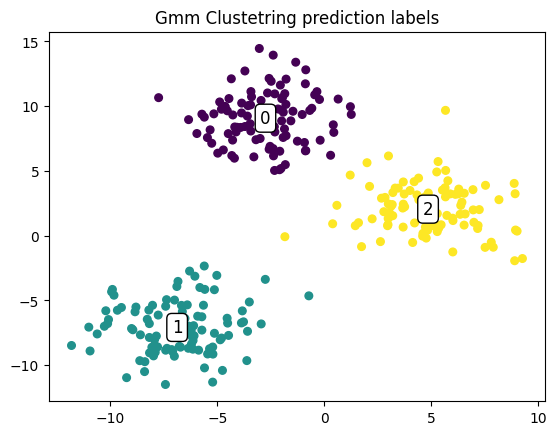

In [12]:
plt.scatter(data[:,0], data[:,1], c=predited_labels, cmap='viridis',s=30,label='cluster_points')

for idx, (x,y) in enumerate(cluster_center):
  plt.text(x,y, str(idx), color='black',fontsize=12, ha='center', va='center',
          bbox=dict(facecolor='white',edgecolor='black',boxstyle='round,pad=0.3'))
plt.title('Gmm Clustetring prediction labels')
plt.show()

In [13]:
#Predicting a datapoints

new_points = [[0,3]]

In [16]:
predicted_cluster = gmm.predict(new_points)
print(predicted_cluster[0])

2


In [17]:
probablities = gmm.predict_proba(new_points)

In [18]:
probablities

array([[3.65071761e-02, 6.71974709e-07, 9.63492152e-01]])

In [19]:
#babe ruth card values

np.random.seed(42)

In [21]:
cluster_1 = np.random.normal(loc=5000, scale=2500, size=300)

In [22]:
cluster_1 = cluster_1[cluster_1 > 0]

In [23]:
cluster_2 = np.random.normal(loc=20000, scale=5000, size=100)

In [24]:
cluster_2 = cluster_2[cluster_2 > 0]

In [25]:
prices = np.concatenate([cluster_1, cluster_2]).reshape(-1,1)

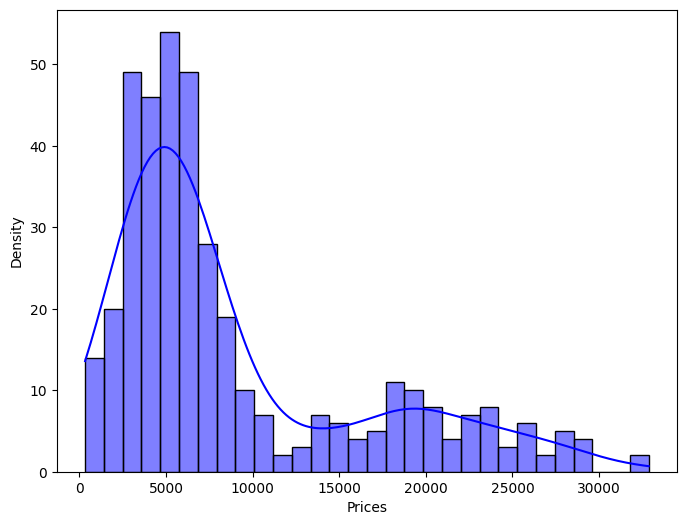

In [26]:
#plot the prices

prices_flat = prices.flatten()

plt.figure(figsize=(8,6))
sns.histplot(prices_flat, kde=True, bins = 30,color='blue',edgecolor='black')
plt.xlabel("Prices")
plt.ylabel("Density")
plt.show()

In [27]:
gmm = GaussianMixture(n_components=2, random_state=42)

In [28]:
gmm.fit(prices)

GaussianMixture(n_components=2, random_state=42)

In [29]:
predicted_labels = gmm.predict(prices)

In [31]:
data_df = pd.DataFrame({
    'Prices':prices.flatten(),
    'Cluster':predicted_labels


})

In [32]:
print(data_df.head(10))

        Prices  Cluster
0  2927.512473        0
1  3599.547400        0
2  6868.234013        0
3  6525.925664        0
4  4947.746015        0
5  5293.318458        0
6  8194.162239        0
7  3521.071528        0
8  6367.743453        0
9  4494.518369        0


In [34]:
most_expensive = data_df.sort_values(by='Prices', ascending=False).head(10)

In [35]:
most_expensive

,Prices,Cluster
347,32866.799016,1
307,32228.759898,1
315,29410.122482,1
298,29383.979063,1
343,29244.780475,1
370,28761.352217,1
334,28345.107626,1
317,27965.933133,1
324,27647.751597,1
360,27519.964943,1
